In [2]:
from nemo.collections.tts.models import T5TTS_Model, T5TTS_Discriminator
from nemo.collections.tts.data.text_to_speech_dataset import T5TTSDataset, DatasetSample
from omegaconf.omegaconf import OmegaConf, open_dict
import torch
import os
import soundfile as sf
from IPython.display import display, Audio
import numpy as np
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"]="0"

### Checkpoint Paths

In [3]:
fs_12_5 = False
if fs_12_5:
    #hparams_file = "/datap/misc/continuouscheckpoints/lt/localtransformer//koel_12.5_FPS_causal_13codebooks_codecmodel_context5sec_LTN1_hparams.yaml"
    #checkpoint_file = "/datap/misc/continuouscheckpoints/lt/localtransformer/koel_12.5_FPS_causal_13codebooks_codecmodel_context5sec_LTN1_epoch289.ckpt"
    checkpoint_file = "/datap/misc/continuouscheckpoints/lt/localtransformer/koel_12.5_FPS_causal_13codebooks_codecmodel_context5sec_LTN3_epoch270.ckpt"
    hparams_file = "/datap/misc/continuouscheckpoints/lt/localtransformer/koel_12.5_FPS_causal_13codebooks_codecmodel_context5sec_LTN3_hparams.yaml"
    codecmodel_path = "/datap/misc/checkpoints/12.5_FPS_causal_13codebooks_codecmodel.nemo"


    disc_checkpoint_file = "disc_training_frozen_audio_emb_heads4_dim128/T5TTS_Discriminator/0/checkpoints/T5TTS_Discriminator--val_loss=0.3054-epoch=177.ckpt"
    disc_hparams_file = "disc_training_frozen_audio_emb_heads4_dim128/T5TTS_Discriminator/0/hparams.yaml"
else: # 21 fps
    checkpoint_file = "/datap/misc/continuouscheckpoints/lt/localtransformer/dc_yum_recipe_withLT_epoch233.ckpt"
    hparams_file = "/datap/misc/continuouscheckpoints/lt/localtransformer/dc_yum_recipe_withLT_hparams.yaml"
    codecmodel_path = "/datap/misc/checkpoints/AudioCodec_21Hz_no_eliz.nemo"

    disc_checkpoint_file = "disc_21_128/T5TTS_Discriminator/0/checkpoints/T5TTS_Discriminator--val_loss=0.4759-epoch=114.ckpt"
    disc_hparams_file = "disc_21_128/T5TTS_Discriminator/0/hparams.yaml"


# Temp out dir for saving audios
out_dir = "/datap/misc/t5tts_inference_notebook_samples"
if not os.path.exists(out_dir):
    os.makedirs(out_dir)

# Load discriminator

In [4]:
disc_model_cfg = OmegaConf.load(disc_hparams_file).cfg
disc_model_cfg.train_ds = None
disc_model_cfg.validation_ds = None
disc_model = T5TTS_Discriminator(cfg=disc_model_cfg)

disc_weights = torch.load(disc_checkpoint_file, weights_only=False)
disc_model.load_state_dict(disc_weights['state_dict'])

disc_model.cuda()
disc_model.eval()


T5TTS_Discriminator(
  (audio_embeddings): ModuleList(
    (0-8): 9 x Embedding(2048, 768)
  )
  (audio_emb_to_model_proj): Linear(in_features=768, out_features=128, bias=True)
  (encoder): Transformer(
    (dropout): Dropout(p=0.1, inplace=False)
    (norm_out): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (layers): ModuleList(
      (0-3): 4 x TransformerLayer(
        (norm_self): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (self_attention): SelfAttention(
          (o_net): Linear(in_features=128, out_features=128, bias=False)
          (dropout): Dropout(p=0.1, inplace=False)
          (qkv_net): Linear(in_features=128, out_features=384, bias=False)
        )
        (norm_pos_ff): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (pos_ff): PositionwiseConvFF(
          (non_linearity): GELU(approximate='tanh')
          (proj): ConvolutionLayer(
            (conv): Conv1d(128, 512, kernel_size=(1,), stride=(1,), bias=False)
          )
 

### Load Model

In [5]:
model_cfg = OmegaConf.load(hparams_file).cfg

with open_dict(model_cfg):
    model_cfg.codecmodel_path = codecmodel_path
    if hasattr(model_cfg, 'text_tokenizer'):
        # Backward compatibility for models trained with absolute paths in text_tokenizer
        model_cfg.text_tokenizer.g2p.phoneme_dict = "scripts/tts_dataset_files/ipa_cmudict-0.7b_nv23.01.txt"
        model_cfg.text_tokenizer.g2p.heteronyms = "scripts/tts_dataset_files/heteronyms-052722"
        model_cfg.text_tokenizer.g2p.phoneme_probability = 1.0
    model_cfg.train_ds = None
    model_cfg.validation_ds = None


model = T5TTS_Model(cfg=model_cfg)
print("Loading weights from checkpoint")
ckpt = torch.load(checkpoint_file, weights_only=False)
model.load_state_dict(ckpt['state_dict'])
print("Loaded weights.")

model.use_kv_cache_for_inference = True

model.cuda()
model.eval()

[NeMo W 2025-03-22 02:06:50 nemo_logging:405] `<class 'nemo.collections.tts.g2p.models.i18n_ipa.IpaG2p'>` is experimental and not ready for production yet. Use at your own risk.
[NeMo W 2025-03-22 02:06:51 nemo_logging:405] apply_to_oov_word=None, This means that some of words will remain unchanged if they are not handled by any of the rules in self.parse_one_word(). This may be intended if phonemes and chars are both valid inputs, otherwise, you may see unexpected deletions in your input.
[NeMo W 2025-03-22 02:06:51 nemo_logging:405] `<class 'nemo.collections.common.tokenizers.text_to_speech.tts_tokenizers.IPATokenizer'>` is experimental and not ready for production yet. Use at your own risk.
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should o

[NeMo I 2025-03-22 02:06:54 nemo_logging:393] Vector quantizer does not support commit loss.
[NeMo I 2025-03-22 02:06:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-03-22 02:06:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-03-22 02:06:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-03-22 02:06:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-03-22 02:06:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-03-22 02:06:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-03-22 02:06:56 nemo_logging:393] PADDING: 1
[NeMo I 2025-03-22 02:06:57 nemo_logging:393] Model AudioCodecModel was successfully restored from /datap/misc/checkpoints/AudioCodec_21Hz_no_eliz.nemo.
Loading weights from checkpoint
Loaded weights.


T5TTS_Model(
  (audio_embeddings): ModuleList(
    (0-7): 8 x Embedding(2048, 768)
  )
  (text_embedding): Embedding(98, 768)
  (t5_encoder): Transformer(
    (dropout): Dropout(p=0.1, inplace=False)
    (norm_out): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (layers): ModuleList(
      (0-5): 6 x TransformerLayer(
        (norm_self): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (self_attention): SelfAttention(
          (o_net): Linear(in_features=768, out_features=768, bias=False)
          (dropout): Dropout(p=0.1, inplace=False)
          (qkv_net): Linear(in_features=768, out_features=2304, bias=False)
        )
        (norm_pos_ff): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (pos_ff): PositionwiseConvFF(
          (non_linearity): GELU(approximate='tanh')
          (proj): ConvolutionLayer(
            (conv): Conv1d(768, 3072, kernel_size=(3,), stride=(1,), padding=(1,), bias=False)
          )
          (o_net): ConvolutionLay

### Initialize Dataset class and helper functions

In [6]:
test_dataset = T5TTSDataset(
    dataset_meta={},
    sample_rate=model_cfg.sample_rate,
    min_duration=0.5,
    max_duration=20,
    codec_model_downsample_factor=model_cfg.codec_model_downsample_factor,
    bos_id=model.bos_id,
    eos_id=model.eos_id,
    context_audio_bos_id=model.context_audio_bos_id,
    context_audio_eos_id=model.context_audio_eos_id,
    audio_bos_id=model.audio_bos_id,
    audio_eos_id=model.audio_eos_id,
    num_audio_codebooks=model_cfg.num_audio_codebooks,
    prior_scaling_factor=None,
    load_cached_codes_if_available=True,
    dataset_type='test',
    tokenizer_config=None,
    load_16khz_audio=model.model_type == 'single_encoder_sv_tts',
    use_text_conditioning_tokenizer=model.use_text_conditioning_encoder,
    pad_context_text_to_max_duration=model.pad_context_text_to_max_duration,
    context_duration_min=model.cfg.get('context_duration_min', 5.0),
    context_duration_max=model.cfg.get('context_duration_max', 5.0),
)
test_dataset.text_tokenizer, test_dataset.text_conditioning_tokenizer = model._setup_tokenizers(model.cfg, mode='test')



def get_audio_duration(file_path):
    with sf.SoundFile(file_path) as audio_file:
        # Calculate the duration
        duration = len(audio_file) / audio_file.samplerate
        return duration

def create_record(text, context_audio_filepath=None, context_text=None):
    dummy_audio_fp = os.path.join(out_dir, "dummy_audio.wav")
    dummy_audio = sf.write(dummy_audio_fp, np.zeros(22050 * 3), 22050)  # 3 seconds of silence
    record = {
        'audio_filepath' : dummy_audio_fp,
        'duration': 3.0,
        'text': text,
        'speaker': "dummy",
    }
    if context_text is not None:
        assert context_audio_filepath is None
        record['context_text'] = context_text
    else:
        assert context_audio_filepath is not None
        record['context_audio_filepath'] = context_audio_filepath
        record['context_audio_duration'] = get_audio_duration(context_audio_filepath)
    
    return record

[NeMo W 2025-03-22 02:06:58 nemo_logging:405] `<class 'nemo.collections.tts.g2p.models.i18n_ipa.IpaG2p'>` is experimental and not ready for production yet. Use at your own risk.
[NeMo W 2025-03-22 02:06:59 nemo_logging:405] apply_to_oov_word=None, This means that some of words will remain unchanged if they are not handled by any of the rules in self.parse_one_word(). This may be intended if phonemes and chars are both valid inputs, otherwise, you may see unexpected deletions in your input.
[NeMo W 2025-03-22 02:06:59 nemo_logging:405] `<class 'nemo.collections.common.tokenizers.text_to_speech.tts_tokenizers.IPATokenizer'>` is experimental and not ready for production yet. Use at your own risk.


### Set transcript and context pairs to test

In [7]:
import pprint
# Change sample text and prompt audio/text here
audio_base_dir = "/"
test_entries = [
    create_record(
        text="The recollection of a unique event cannot, so Bergson contends, be wholly constituted by habit, and is in fact something radically different from the memory which is habit.",
        context_text="Speaker and Emotion: | Language:en Dataset:Riva Speaker:Rodney_WIZWIKI |",
        #context_audio_filepath="/home/rfejgin/contexts/sqam_cd_49_5sec_mono.wav"
        #context_audio_filepath="/home/rfejgin/contexts/GTC_FALL_2021_KEYNOTE_V0Only-44khz-16bit-mono_CH07_0042__5s.wav",
    ),
    # create_record(
    #     text="This is a second sentence to test the model. And it should be longer than the first one.",
    #     context_audio_filepath="/home/rfejgin/contexts/GTC_FALL_2021_KEYNOTE_V0Only-44khz-16bit-mono_CH07_0042__5s.wav",
    # ),    
]

data_samples = []
for entry in test_entries:
    dataset_sample = DatasetSample(
        dataset_name="sample",
        manifest_entry=entry,
        audio_dir=audio_base_dir,
        feature_dir=audio_base_dir,
        text=entry['text'],
        speaker=None,
        speaker_index=0,
        tokenizer_names=["english_phoneme"], # Change this for multilingual: "english_phoneme", "spanish_phoneme", "english_chartokenizer", "german_chartokenizer".. 
    )
    data_samples.append(dataset_sample)
    
test_dataset.data_samples = data_samples

test_data_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=1,
    collate_fn=test_dataset.collate_fn,
    num_workers=0,
    shuffle=False
)

### Generate With Prior

Processing batch 0 out of 1
Decoding timestep 0
Decoding timestep 20
Decoding timestep 40
Decoding timestep 60
Decoding timestep 80
Decoding timestep 100
Decoding timestep 120
Decoding timestep 140
Decoding timestep 160
Decoding timestep 180
Decoding timestep 200
End detected for item 0 at timestep 202
All ends reached
generation time 4.24834132194519
{'batch_size': 1,
 'max_frames_generated': 203,
 'rtf': 2.668409992926579,
 'time_to_first_prediction': 0.022678852081298828,
 'tts_generation_time': 3.4307875633239746,
 'tts_generation_time_per_frame': 0.01690043134642352}
The recollection of a unique event cannot, so Bergson contends, be wholly constituted by habit, and is in fact something radically different from the memory which is habit.
Prior Used? False
use_local_transformer False
resample_and_rank? False
Mean raw preds: -0.32
Min raw preds:  -8.05
resample_threshold: None
resample_counter: 0
reample percentage: 0.00%
checkpoint: /datap/misc/continuouscheckpoints/lt/localtransfor

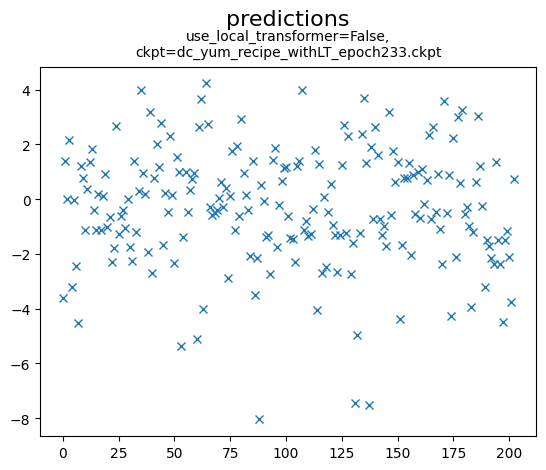

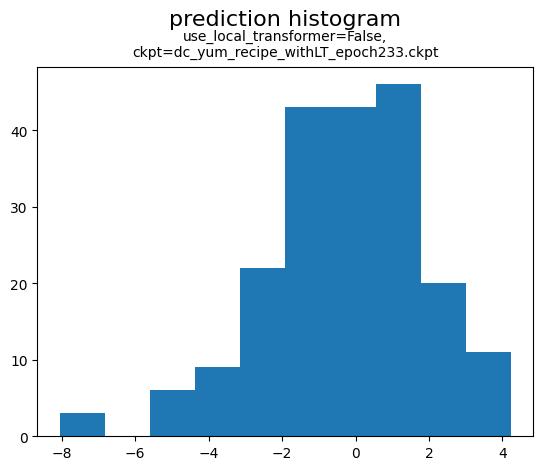

------------------------------------
------------------------------------
Decoding timestep 0
Resampling at timestep 0
Resampling at timestep 8
Resampling at timestep 9
Resampling at timestep 14
Resampling at timestep 15
Decoding timestep 20
Resampling at timestep 29
Resampling at timestep 34
Resampling at timestep 38
Decoding timestep 40
Resampling at timestep 41
Resampling at timestep 45
Resampling at timestep 48
Resampling at timestep 50
Resampling at timestep 54
Resampling at timestep 55
Decoding timestep 60
Resampling at timestep 62
Resampling at timestep 78
Decoding timestep 80
Resampling at timestep 81
Resampling at timestep 92
Resampling at timestep 93
Resampling at timestep 95
Resampling at timestep 97
Decoding timestep 100
Resampling at timestep 100
Resampling at timestep 105
Resampling at timestep 118
Decoding timestep 120
Resampling at timestep 129
Resampling at timestep 133
Decoding timestep 140
Resampling at timestep 154
Decoding timestep 160
Resampling at timestep 160
Re

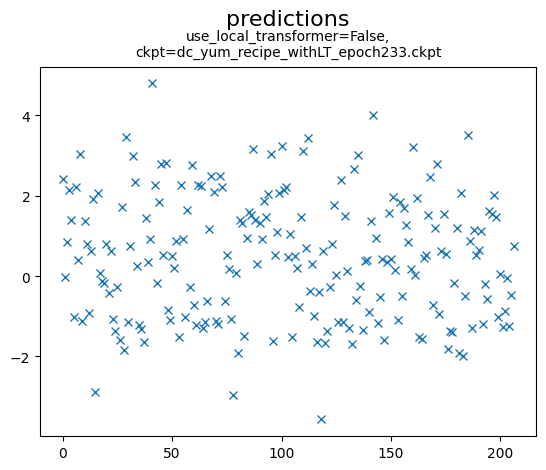

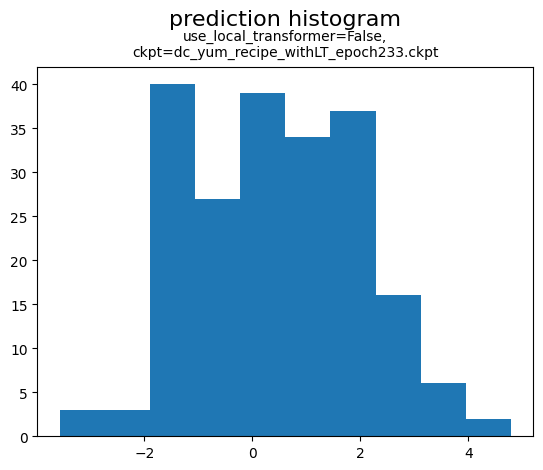

------------------------------------
------------------------------------


In [29]:
import matplotlib.pyplot as plt

def title_with_subtitle(ax, title, subtitle):
    ax.set_title(title, fontsize=16, pad=30)
    ax.text(
        0.5, 1.02, subtitle, 
        transform=ax.transAxes, 
        fontsize=10, 
        ha='center', 
        va='bottom'
    )

item_idx = 0
for bidx, batch in enumerate(test_data_loader):
    print("Processing batch {} out of {}".format(bidx, len(test_data_loader)))
    model.t5_decoder.reset_cache(use_cache=True)
    batch_cuda ={}
    for key in batch:
        if isinstance(batch[key], torch.Tensor):
            batch_cuda[key] = batch[key].cuda()
        else:
            batch_cuda[key] = batch[key]
    import time
    st = time.time()
    
    for _ in range(1):
        for resample_threshold in [None, -2.0]:
            for use_local_transformer_for_inference in [False]: #, True]:#, True]:
                for apply_prior in [False]:
                    for resample_and_rank in [False]:#[True, False]:
                        predicted_audio, predicted_audio_lens, predicted_codes, predicted_codes_lens, rtf_metrics, cross_attn_np, all_heads_attn_np, disc_preds, disc_preds_raw, resample_counter = model.infer_batch(
                            batch_cuda, 
                            max_decoder_steps=430, 
                            temperature=0.6, 
                            topk=80, 
                            use_cfg=False,
                            cfg_scale=2.5,
                            prior_epsilon=0.1,
                            lookahead_window_size=5,
                            return_cross_attn_probs=True,
                            estimate_alignment_from_layers=[5],
                            apply_attention_prior=apply_prior,
                            apply_prior_to_layers=[0,1,2,3,4,5,6,7,8,9,10,11],
                            compute_all_heads_attn_maps=True,
                            start_prior_after_n_audio_steps=0,
                            use_local_transformer_for_inference=use_local_transformer_for_inference,
                            discriminator=disc_model,
                            resample_and_rank=resample_and_rank,
                            resample_and_rank_count=10,
                            resample_threshold=resample_threshold,
                        )
                        if False:
                            #print("Discriminator Predictions:", disc_preds)
                            acc = (disc_preds == False).float().sum() / disc_preds.numel()
                            print(f"Discriminator accuracy: {acc*100:.2f}%")
                        print("generation time", time.time() - st)
                        show_attn_maps = False
                        pprint.pprint(rtf_metrics)
                        for idx in range(predicted_audio.size(0)):
                            predicted_audio_np = predicted_audio[idx].float().detach().cpu().numpy()
                            predicted_audio_np = predicted_audio_np[:predicted_audio_lens[idx]]
                            audio_path = os.path.join(out_dir, f"predicted_audio_{item_idx}.wav")
                            sf.write(audio_path, predicted_audio_np, model.cfg.sample_rate)
                            print(test_entries[bidx]['text'])
                            print("Prior Used?", apply_prior)
                            print("use_local_transformer", use_local_transformer_for_inference)
                            print("resample_and_rank?", resample_and_rank)
                            print(f"Mean raw preds: {disc_preds_raw.mean().cpu().item():.2f}")
                            print(f"Min raw preds:  {disc_preds_raw.min().cpu().item():.2f}")
                            print(f"resample_threshold: {resample_threshold}")
                            print(f"resample_counter: {resample_counter}")
                            print(f"reample percentage: {(resample_counter / len(disc_preds_raw))*100:.2f}%")
                            print(f"checkpoint: {checkpoint_file}")
                            display(Audio(audio_path))
                            item_idx += 1
                            
                            if True:
                                disc_preds_raw = disc_preds_raw.cpu().numpy()                    

                                # Discriminator Predictions
                                fig, ax = plt.subplots()
                                ax.plot(disc_preds_raw, 'x')
                                title_with_subtitle(ax, f"predictions", f"use_local_transformer={use_local_transformer_for_inference},\nckpt={os.path.basename(checkpoint_file)}")
                                plt.show()

                                # Discriminator Predictions Histogram
                                fig, ax = plt.subplots()
                                plt.hist(disc_preds_raw)
                                title_with_subtitle(ax, f"prediction histogram", f"use_local_transformer={use_local_transformer_for_inference},\nckpt={os.path.basename(checkpoint_file)}")
                                plt.show()
                            if show_attn_maps:
                                plt.imshow(cross_attn_np[idx])
                                plt.show()
    #                     for hidx, head_cross_attn in enumerate(all_heads_attn_np[idx]):
    #                         layer_num = hidx // model.cfg.t5_decoder.xa_n_heads
    #                         head_num = hidx % model.cfg.t5_decoder.xa_n_heads
    #                         print("item, layer, head", idx, layer_num, head_num)
    #                         plt.imshow(all_heads_attn_np[idx][hidx])
    #                         plt.show()

                print("------------------------------------")
                print("------------------------------------")

In [26]:
disc_preds_raw[70:80]

array([ 1.1005874 ,  2.647743  ,  1.2826698 , -0.00299602, -2.3850274 ,
        1.1797751 , -0.9572159 , -0.5900234 ,  0.16814551, -0.17696816],
      dtype=float32)

In [27]:
(disc_preds_raw < -3.5).sum() / len(disc_preds_raw)

0.0049504950495049506

In [28]:
np.argmin(disc_preds_raw)

133